# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


Os dados são criados a seguir:

In [24]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




Unilateral a direita porque quero verificar se B é maior que A, são esperados valores positivos e maiores a direita(toda a região crítica do teste fica concentrada no lado direito da distribuição)

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [25]:
#antes só para gerar não quer dizer que os valores vão ser iguais aos que vc pediu.
print('média A:',np.mean(amostra_estrategia_A))
print('média B:',np.mean(amostra_estrategia_B))

print('Var A:',np.var(amostra_estrategia_A, ddof=1))
print('Var B:',np.var(amostra_estrategia_B, ddof=1))

média A: 71.40559272313098
média B: 74.74868110507046
Var A: 129.2654943565623
Var B: 110.4700206552835


B apresenta média maior que A e também uma variância menor indicando que seus valores estão menos dispersos, mas é preciso confirmar com os testes se essa média maior é estatisticamente significativa.
    

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [26]:
mean_A = np.mean(amostra_estrategia_A)
mean_B = np.mean(amostra_estrategia_B)

var_A = np.var(amostra_estrategia_A, ddof=1)
var_B = np.var(amostra_estrategia_B, ddof=1)

n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

# Estatística Z
z = (mean_B - mean_A) / np.sqrt(var_A/n_A + var_B/n_B)

# p-valor unilateral à direita
p_value = 1 - stats.norm.cdf(z)

print("Estatística Z:", z)
print("p-valor:", p_value)

Estatística Z: 1.5267455833477102
p-valor: 0.06341214386181693


In [32]:

nivel_significancia == 0.05
if p_value < nivel_significancia:
    print("Rejeitamos a hipotese nula: A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.")
else:
    print("Não temos as evidências suficientes para rejeitar a hipótese nula:A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.")
    
    

Não temos as evidências suficientes para rejeitar a hipótese nula:A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.


Após o teste observamos que o valor de p é maior que o nível de significancia(está fora da área crítica-passou da área de significancia) portanto, não é possível afirmar com confiança que as médias são maiores. Mesmo a média de B sendo maior que A a diferença não foi estatisticamente significativa. Há uma probabilidade de 6% de se observar um z 1.52 sob a hipotese nula.

# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

#esse ela fez na aula com t
fig, ax = plt.subplots(figsize = (10,5))
mu = 0 #medida da distribuição t
variance = 1 #distribuição t sobre a h nula
sigma = variance **.5  #é a dp da distribuição t

x = np.linspace (mu - 3*sigma, mu+ 3* sigma, 100)
y = stats.t.pdf(x, len(amostra_estrategia_A) + len(amostra_estrategia_B) -2)

low = stats.t.pdf (.95, len (amostra_estrategia_A)+ len(amostra_estrategia_B)-2)

high = np.inf

ax.plot(x,y, label ="Densidade")

ax.vlines(x=[x=[t_statistics], ymin=0, ymax=y.max(),colors='r', linestyles='dotted', label='Valor Observado (Z)')
plt.fill_between(x, y, where = (low<x) & (x>high), alpha =.5, label='Area crítica')

plt.legend()
plt.xlabel('Valores de X')
plt.ylabel('Densidade')
plt.title('Distribuição com destaque para crítica')
plt.show()

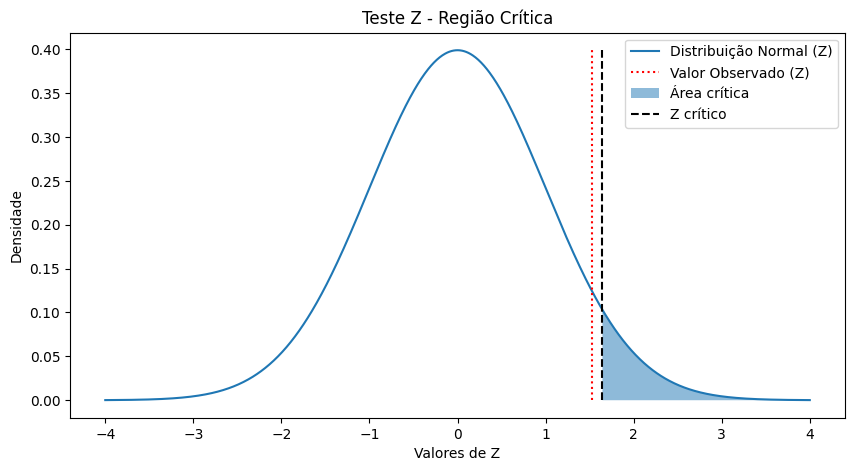

In [41]:
fig, ax = plt.subplots(figsize=(10,5))

# eixo x (distribuição normal padrão)
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

# nível de significância
alpha = 0.05

# valor crítico (teste unilateral à direita)
z_critico = stats.norm.ppf(1 - alpha)

# curva
ax.plot(x, y, label="Distribuição Normal (Z)")

# valor observado
ax.vlines(x=z, ymin=0, ymax=y.max(),
          colors='r', linestyles='dotted',
          label='Valor Observado (Z)')

# região crítica
x_crit = x[x >= z_critico]
y_crit = stats.norm.pdf(x_crit)

ax.fill_between(x_crit, y_crit, alpha=0.5, label='Área crítica')

# linha do valor crítico
ax.vlines(x=z_critico, ymin=0, ymax=y.max(),
          colors='black', linestyles='dashed',
          label='Z crítico')

plt.legend()
plt.xlabel('Valores de Z')
plt.ylabel('Densidade')
plt.title('Teste Z - Região Crítica')
plt.show()

No gráfico a área sombreada mostra a região crítica com os 5% de significancia, encontramos um z próximo mas fora da área crítica o que condiz com o valor de p de 0.063 superior ao nível de significância estipulado em 0.05. Quando o valor de p é maior que o nível de significancia signfica que ele está fora da área crítica, que passou da área determinada como de significancia e não podemos afirmar que existe relevância estatística.